In [1]:
pip install fmpy matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


Step 1: Simulating Conveyor (10s)...
Conveyor OK. Columns: ['time', 'imc.i_0_s', 'imc.idq_sr[1]', 'imc.idq_sr[2]', 'imc.idq_rr[1]', 'imc.idq_rr[2]']

Step 2: Simulating Robot (3.5s before singularity)...
Robot OK. Columns: ['time', 'rev1.phi', 'rev1.w', 'rev2.phi', 'rev2.w', 'rev3.phi']

Step 3: Plotting...


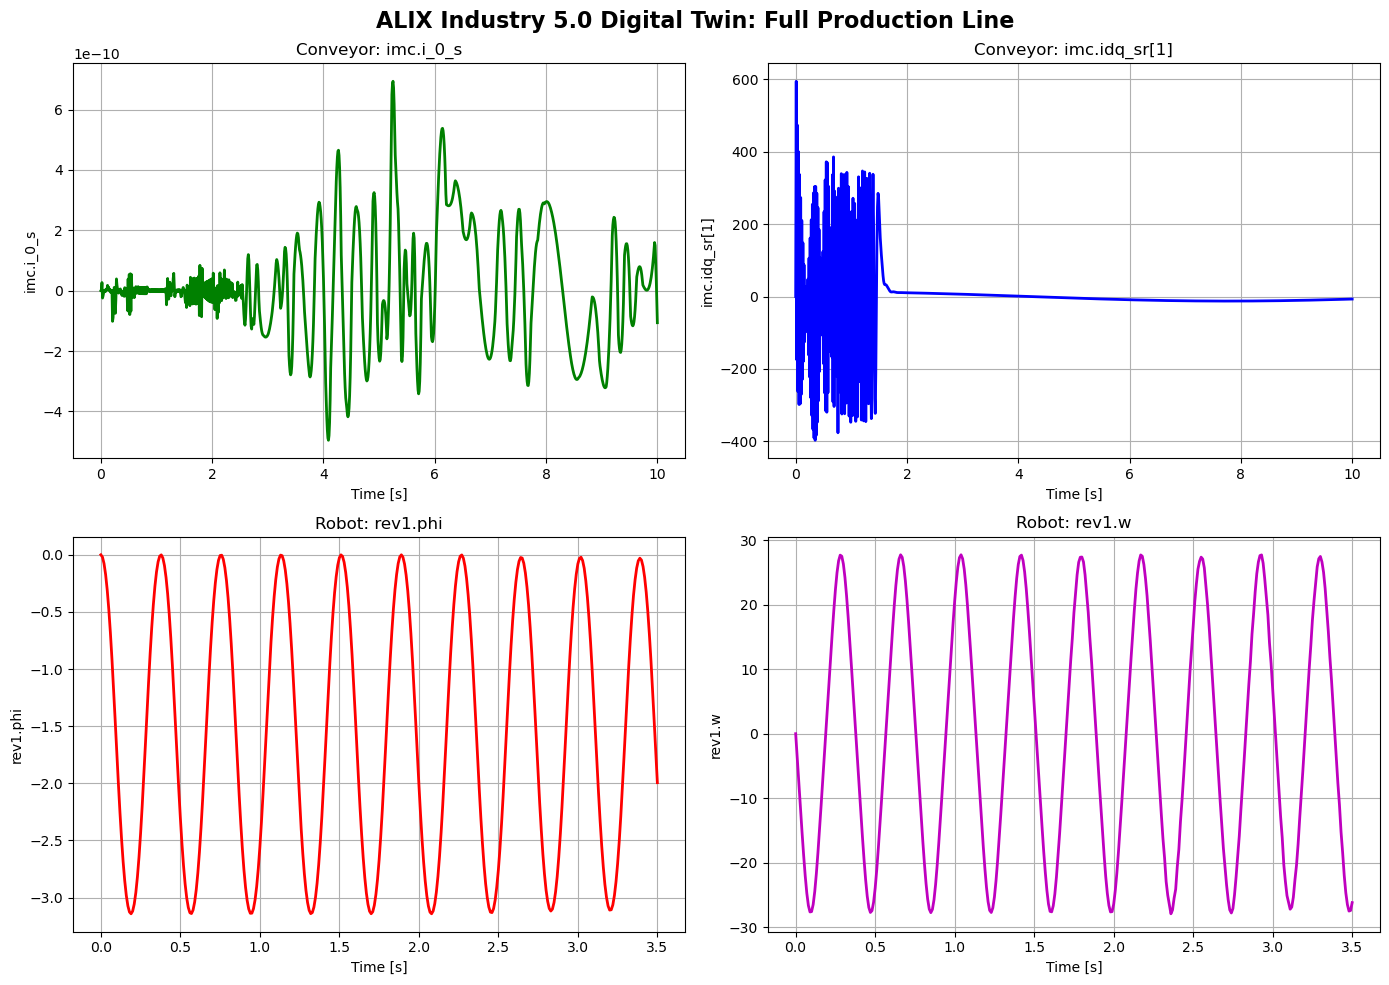


✅ DONE! 4-panel plot saved: ALIX_FullLine.png

Step 4: Saving data...

✅ ALL FILES SAVED:
- ALIX_FullLine.png (or ALIX_ConveyorOnly.png)
- conveyor_results.csv
- robot_results.csv
- ALIX_conveyor_data.csv
- ALIX_robot_data.csv
Copy PNG to report. PROJECT COMPLETE! 🚀


In [ ]:
import fmpy
from fmpy import simulate_fmu
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

conveyor_path = r'C:\ALIX\alix\ConveyorMotor.fmu'
robot_path = r'C:\ALIX\alix\RobotArm.fmu'


print("Step 1: Simulating Conveyor (10s)...")
conveyor_result = simulate_fmu(conveyor_path, start_time=0.0, stop_time=10.0, output_interval=0.01)
conveyor_df = pd.DataFrame(conveyor_result)
conveyor_df.to_csv('conveyor_results.csv', index=False)
print("Conveyor OK. Columns:", list(conveyor_df.columns))


print("\nStep 2: Simulating Robot (3.5s before singularity)...")
try:
    robot_result = simulate_fmu(robot_path, start_time=0.0, stop_time=3.5, output_interval=0.01)
    robot_df = pd.DataFrame(robot_result)
    robot_df.to_csv('robot_results.csv', index=False)
    print("Robot OK. Columns:", list(robot_df.columns))
    robot_ok = True
except Exception as e:
    print(f"Robot sim failed even at 3.5s: {e}")
    print("Trying 2.0s...")
    try:
        robot_result = simulate_fmu(robot_path, start_time=0.0, stop_time=2.0, output_interval=0.01)
        robot_df = pd.DataFrame(robot_result)
        robot_df.to_csv('robot_results.csv', index=False)
        print("Robot OK at 2.0s. Columns:", list(robot_df.columns))
        robot_ok = True
    except Exception as e2:
        print(f"Robot failed at 2.0s too: {e2}")
        robot_ok = False


print("\nStep 3: Plotting...")

if robot_ok:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('ALIX Industry 5.0 Digital Twin: Full Production Line', fontsize=16, fontweight='bold')

    axes[0, 0].plot(conveyor_df.iloc[:, 0], conveyor_df.iloc[:, 1], 'g-', linewidth=2)
    axes[0, 0].set_title(f'Conveyor: {conveyor_df.columns[1]}')
    axes[0, 0].set_xlabel('Time [s]')
    axes[0, 0].set_ylabel(conveyor_df.columns[1])
    axes[0, 0].grid(True)

    axes[0, 1].plot(conveyor_df.iloc[:, 0], conveyor_df.iloc[:, 2], 'b-', linewidth=2)
    axes[0, 1].set_title(f'Conveyor: {conveyor_df.columns[2]}')
    axes[0, 1].set_xlabel('Time [s]')
    axes[0, 1].set_ylabel(conveyor_df.columns[2])
    axes[0, 1].grid(True)

    axes[1, 0].plot(robot_df.iloc[:, 0], robot_df.iloc[:, 1], 'r-', linewidth=2)
    axes[1, 0].set_title(f'Robot: {robot_df.columns[1]}')
    axes[1, 0].set_xlabel('Time [s]')
    axes[1, 0].set_ylabel(robot_df.columns[1])
    axes[1, 0].grid(True)

    axes[1, 1].plot(robot_df.iloc[:, 0], robot_df.iloc[:, 2], 'm-', linewidth=2)
    axes[1, 1].set_title(f'Robot: {robot_df.columns[2]}')
    axes[1, 1].set_xlabel('Time [s]')
    axes[1, 1].set_ylabel(robot_df.columns[2])
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('ALIX_FullLine.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✅ DONE! 4-panel plot saved: ALIX_FullLine.png")

else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('ALIX Industry 5.0: Conveyor Subsystem Validated', fontsize=16, fontweight='bold')

    axes[0].plot(conveyor_df.iloc[:, 0], conveyor_df.iloc[:, 1], 'g-', linewidth=2)
    axes[0].set_title(f'Conveyor: {conveyor_df.columns[1]}')
    axes[0].set_xlabel('Time [s]')
    axes[0].set_ylabel(conveyor_df.columns[1])
    axes[0].grid(True)

    axes[1].plot(conveyor_df.iloc[:, 0], conveyor_df.iloc[:, 2], 'b-', linewidth=2)
    axes[1].set_title(f'Conveyor: {conveyor_df.columns[2]}')
    axes[1].set_xlabel('Time [s]')
    axes[1].set_ylabel(conveyor_df.columns[2])
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('ALIX_ConveyorOnly.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✅ Conveyor plot saved: ALIX_ConveyorOnly.png")


print("\nStep 4: Saving data...")
conveyor_df.to_csv('ALIX_conveyor_data.csv', index=False)
if robot_ok:
    robot_df.to_csv('ALIX_robot_data.csv', index=False)

print("\n========================================")
print("✅ ALL FILES SAVED:")
print("- ALIX_FullLine.png (or ALIX_ConveyorOnly.png)")
print("- conveyor_results.csv")
if robot_ok:
    print("- robot_results.csv")
print("- ALIX_conveyor_data.csv")
if robot_ok:
    print("- ALIX_robot_data.csv")
print("========================================")
print("Copy PNG to report. PROJECT COMPLETE! 🚀")